In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [5]:
df = pd.read_csv("salary.csv")

In [6]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [7]:
df.shape

(30, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [9]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.773333,80920.033333
std,3.081192,30709.007944
min,1.100000,37731.000000
25%,3.325000,56751.750000
50%,5.200000,74650.500000
75%,8.575000,108468.750000
max,11.000000,135675.000000


In [10]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [13]:
df[["YearsExperience"]]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.7
9,3.9


In [14]:
df["Salary"]

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      57189
9      63218
10     55794
11     57081
12     61111
13     67938
14     66029
15     83088
16     81363
17     93940
18     91738
19     98273
20    101302
21    113812
22    109431
23    105582
24    116969
25    112635
26    122391
27    128765
28    126345
29    135675
Name: Salary, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = model.predict(X_test)

In [20]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,128765,124873.248443
1,83088,75802.884689
2,105582,112114.953867
3,93940,82672.735615
4,57189,60100.368288
5,63218,62063.182838


In [21]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 41276506.035126485


In [22]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 6424.679449990208


In [23]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9310411767542224


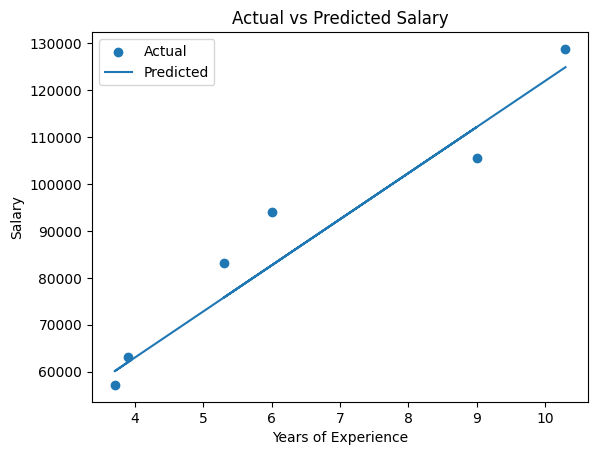

In [24]:
plt.scatter(X_test, y_test, label="Actual")

plt.plot(X_test, y_pred, label="Predicted")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()
plt.show()

In [25]:
joblib.dump(model, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']

In [26]:
import os

print(os.path.exists("salary_prediction_model.pkl"))

True


In [27]:
loaded_model = joblib.load("salary_prediction_model.pkl")

In [28]:
prediction = loaded_model.predict([[5]])

print("Predicted salary for 5 years of experience:", prediction[0])

Predicted salary for 5 years of experience: 72858.66286408967


c:\Users\Ankita\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
